<a href="https://colab.research.google.com/github/lauraaguilargonzalez18/estadisticaverano2026/blob/main/ExamenU2LauraAg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df=pd.read_csv('https://raw.githubusercontent.com/lauraaguilargonzalez18/estadisticaverano2026/refs/heads/main/diabetes_prediction_dataset.csv')
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


El modelo general de Regresión Lineal Múltiple se define matemáticamente como:$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_k X_k + \varepsilon$$Donde $Y$ representa el nivel de glucosa, $X_i$ son los factores predictores, $\beta_0$ es el intercepto, $\beta_i$ son los coeficientes parciales de regresión y $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ representa el término de error aleatorio.

Variable Dependiente (Respuesta / $Y$):blood_glucose_level: Nivel de glucosa en sangre ($mg/dL$).Variables Independientes (Explicativas / $X$):age: Edad del paciente (años).bmi: Índice de masa corporal ($kg/m^2$).HbA1c_level: Nivel de hemoglobina glicosilada ($\%$).hypertension: Presencia de hipertensión arterial ($0 = \text{No}, 1 = \text{Sí}$).heart_disease: Antecedente de enfermedad cardíaca ($0 = \text{No}, 1 = \text{Sí}$).gender: Género del paciente (Categórica: Female, Male, Other).smoking_history: Historial de tabaquismo (Categórica: never, current, former, ever, not current, No Info).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Carga del conjunto de datos en crudo
url_raw = "https://raw.githubusercontent.com/lauraaguilargonzalez18/estadisticaverano2026/refs/heads/main/diabetes_prediction_dataset.csv"
df = pd.read_csv(url_raw)

print("--- Dimensiones del dataset crudo ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

# 2. Transformación de variables categóricas (One-Hot Encoding)
# Se utiliza drop_first=True para evitar la trampa de la multicolinealidad perfecta
df_preprocesado = pd.get_dummies(
    df,
    columns=['gender', 'smoking_history'],
    drop_first=True
)

# Convertir tipos de datos a flotante para análisis numérico continuo
df_preprocesado = df_preprocesado.astype(float)

# Verificación de datos faltantes
print("--- Conteo de Valores Nulos por Variable ---")
print(df_preprocesado.isnull().sum())

--- Dimensiones del dataset crudo ---
Filas: 100000, Columnas: 9

--- Conteo de Valores Nulos por Variable ---
age                            0
hypertension                   0
heart_disease                  0
bmi                            0
HbA1c_level                    0
blood_glucose_level            0
diabetes                       0
gender_Male                    0
gender_Other                   0
smoking_history_current        0
smoking_history_ever           0
smoking_history_former         0
smoking_history_never          0
smoking_history_not current    0
dtype: int64



--- Estadísticas Descriptivas ---


,mean,std,min,50%,max
age,41.885856,22.516840,0.08,43.00,80.00
hypertension,0.074850,0.263150,0.00,0.00,1.00
heart_disease,0.039420,0.194593,0.00,0.00,1.00
bmi,27.320767,6.636783,10.01,27.32,95.69
HbA1c_level,5.527507,1.070672,3.50,5.80,9.00
blood_glucose_level,138.058060,40.708136,80.00,140.00,300.00
diabetes,0.085000,0.278883,0.00,0.00,1.00
gender_Male,0.414300,0.492603,0.00,0.00,1.00
gender_Other,0.000180,0.013415,0.00,0.00,1.00
smoking_history_current,0.092860,0.290238,0.00,0.00,1.00


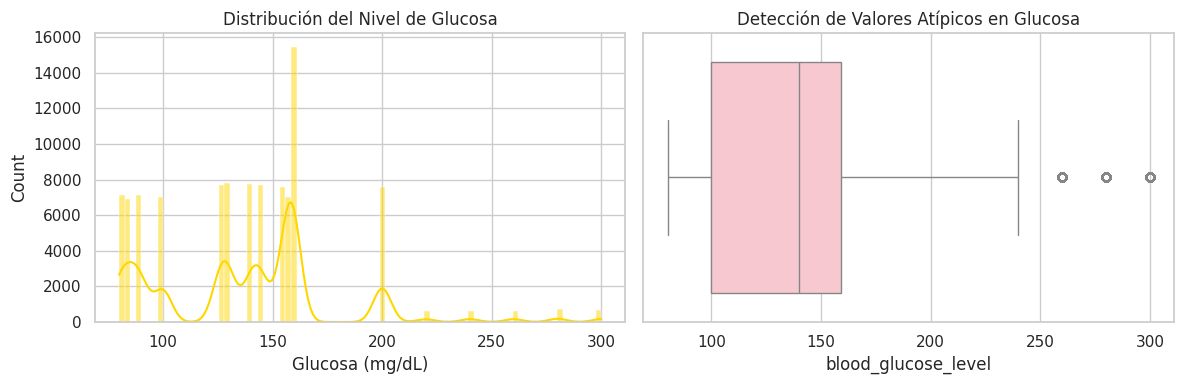

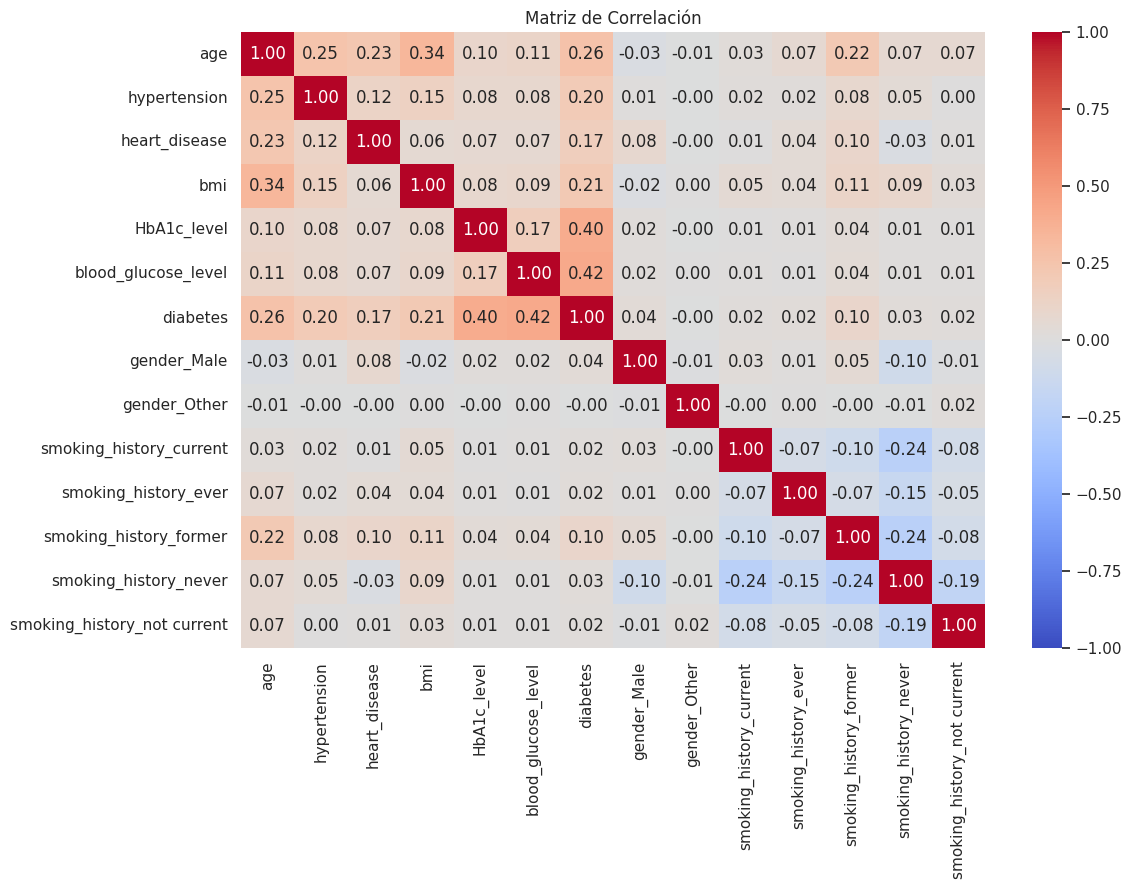

In [10]:
# 1. Resumen de estadísticas descriptivas
print("\n--- Estadísticas Descriptivas ---")
display(df_preprocesado.describe().T[['mean', 'std', 'min', '50%', 'max']])

# 2. Visualización de la Variable Dependiente (Blood Glucose Level)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_preprocesado['blood_glucose_level'], kde=True, color='gold')
plt.title("Distribución del Nivel de Glucosa")
plt.xlabel("Glucosa (mg/dL)")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_preprocesado['blood_glucose_level'], color='pink')
plt.title("Detección de Valores Atípicos en Glucosa")

plt.tight_layout()
plt.show()

# 3. Matriz de Correlación
plt.figure(figsize=(12, 8))
matriz_corr = df_preprocesado.corr()
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlación")
plt.show()

In [4]:
# Definición de predictores (X) excluyendo la variable dependiente y 'diabetes'
variables_X = [col for col in df_preprocesado.columns if col not in ['blood_glucose_level', 'diabetes']]

X = df_preprocesado[variables_X]
Y = df_preprocesado['blood_glucose_level']

# Adición del término constante (Intercepto)
X_const = sm.add_constant(X)

# Cálculo del VIF para cada predictor
vif_df = pd.DataFrame()
vif_df["Variable"] = X_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print("--- Evaluación de Multicolinealidad (VIF) ---")
display(vif_df[vif_df["Variable"] != 'const'].sort_values(by="VIF", ascending=False))

--- Evaluación de Multicolinealidad (VIF) ---


,Variable,VIF
11,smoking_history_never,1.371010
1,age,1.323825
10,smoking_history_former,1.261909
8,smoking_history_current,1.173963
4,bmi,1.160344
12,smoking_history_not current,1.135784
9,smoking_history_ever,1.092961
2,hypertension,1.083487
3,heart_disease,1.076095
6,gender_Male,1.019982


In [5]:
# Ajuste del modelo OLS
modelo_ols = sm.OLS(Y, X_const).fit()

# Imprimir resumen de resultados estadísticos
print(modelo_ols.summary())

                             OLS Regression Results                            
Dep. Variable:     blood_glucose_level   R-squared:                       0.043
Model:                             OLS   Adj. R-squared:                  0.043
Method:                  Least Squares   F-statistic:                     374.3
Date:                 Fri, 24 Jul 2026   Prob (F-statistic):               0.00
Time:                         18:01:30   Log-Likelihood:            -5.1034e+05
No. Observations:               100000   AIC:                         1.021e+06
Df Residuals:                    99987   BIC:                         1.021e+06
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const   

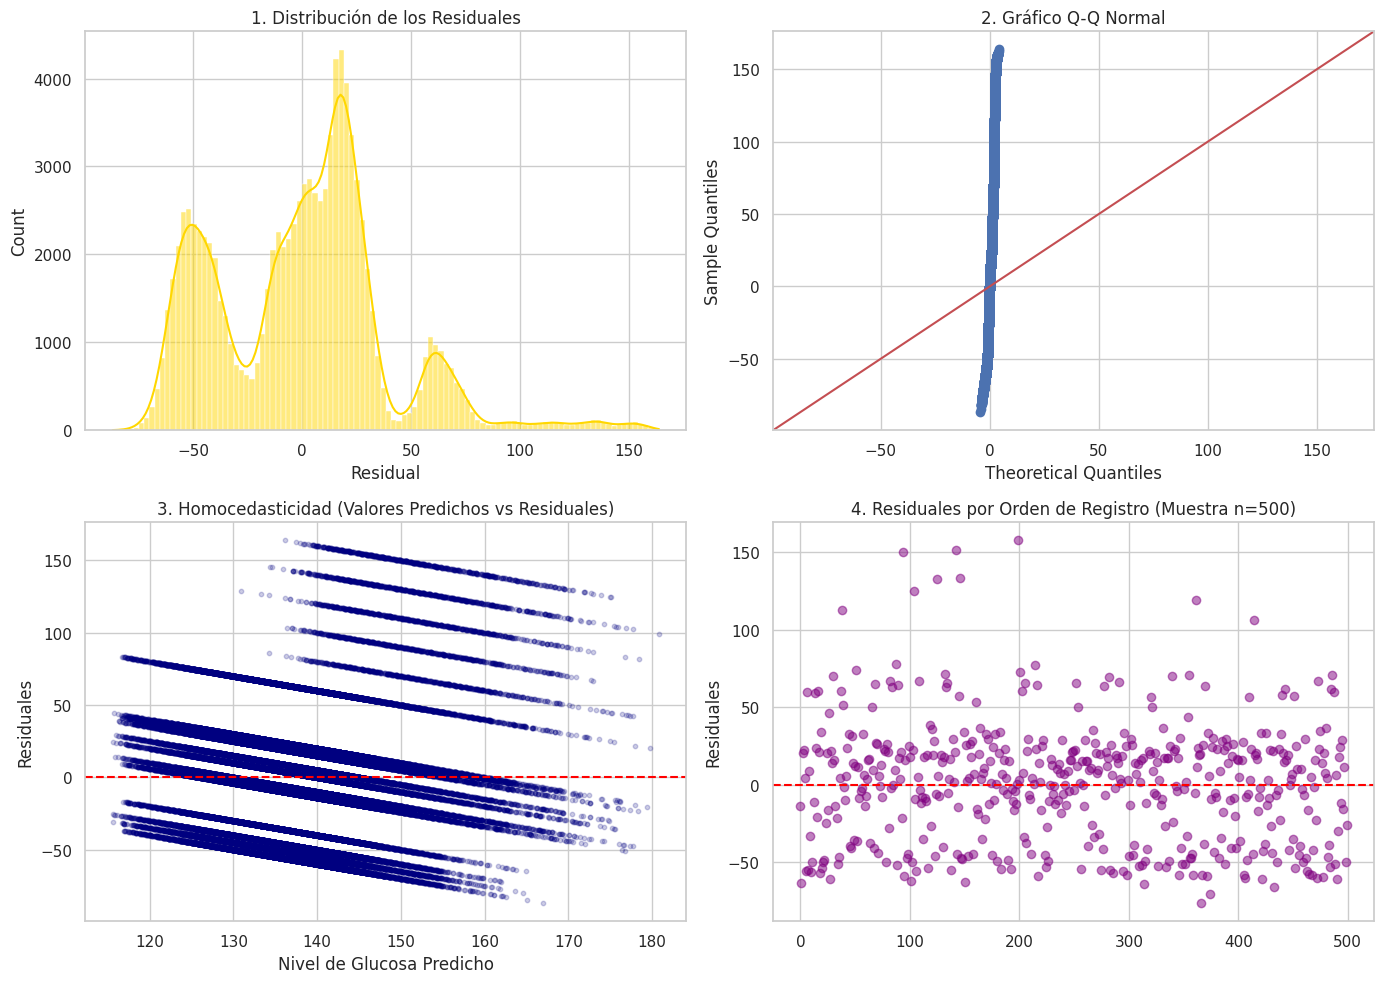

Prueba de Breusch-Pagan (p-valor): 0.0000e+00
Estadístico Durbin-Watson: 2.0029


In [11]:
# Obtención de residuales y valores predichos
residuales = modelo_ols.resid
predicciones = modelo_ols.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A. Distribución de Residuales
sns.histplot(residuales, kde=True, ax=axes[0, 0], color='gold')
axes[0, 0].set_title("1. Distribución de los Residuales")
axes[0, 0].set_xlabel("Residual")

# B. Gráfico Q-Q (Normalidad)
sm.qqplot(residuales, line='45', ax=axes[0, 1])
axes[0, 1].set_title("2. Gráfico Q-Q Normal")

# C. Homocedasticidad (Valores Predichos vs Residuales)
axes[1, 0].scatter(predicciones, residuales, alpha=0.2, s=10, color='navy')
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_title("3. Homocedasticidad (Valores Predichos vs Residuales)")
axes[1, 0].set_xlabel("Nivel de Glucosa Predicho")
axes[1, 0].set_ylabel("Residuales")

# D. Independencia de Errores
axes[1, 1].plot(residuales.iloc[:500], marker='o', linestyle='', alpha=0.5, color='purple')
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title("4. Residuales por Orden de Registro (Muestra n=500)")
axes[1, 1].set_ylabel("Residuales")

plt.tight_layout()
plt.show()

# --- Pruebas Numéricas ---
# Test de Homocedasticidad de Breusch-Pagan
_, p_value_bp, _, _ = sms.het_breuschpagan(residuales, modelo_ols.model.exog)
print(f"Prueba de Breusch-Pagan (p-valor): {p_value_bp:.4e}")

# Test Durbin-Watson para autocorrelación
dw_stat = sm.stats.stattools.durbin_watson(residuales)
print(f"Estadístico Durbin-Watson: {dw_stat:.4f}")